<a href="https://colab.research.google.com/github/naahi-rihan/Python-Projects/blob/main/Intruder_Detection_Training_HITUAV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perimeter Security Platform — Intruder Detection Model
### Dataset deployment, training & accuracy benchmark (Colab / GPU version)

This notebook trains and evaluates the drone's aerial intrusion-detection model end-to-end, live, in this notebook:

1. Pull the **HIT-UAV** dataset from Kaggle — real drone-captured infrared thermal imagery of people, cars, bicycles, and other vehicles (2,898 images), matching the drone's actual mission: aerial thermal verification of a detected intrusion.
2. Evaluate a **stock, untrained YOLOv8n** model as a baseline (zero-shot).
3. **Fine-tune** YOLOv8n on the dataset.
4. Compare baseline vs. fine-tuned accuracy (mAP, precision, recall) on a held-out test set, with charts and sample detections.

**Before running:** in Colab, go to `Runtime → Change runtime type → T4 GPU` so training runs on GPU (much faster than the CPU-only proof-of-concept this replaces). Then `Runtime → Run all`.

Reference: Suo, J. et al. *HIT-UAV: A high-altitude infrared thermal dataset for UAV-based object detection.* Scientific Data 10, 227 (2023). Kaggle mirror: [pandrii000/hituav-a-highaltitude-infrared-thermal-dataset](https://www.kaggle.com/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset)


## 1. Setup

Installs Ultralytics (YOLOv8) and KaggleHub, then downloads the dataset directly from Kaggle.

**Kaggle credentials:** the easiest way in Colab is `Secrets` (key icon in the left sidebar) — add `KAGGLE_USERNAME` and `KAGGLE_KEY` from your Kaggle account (kaggle.com → Settings → Create New Token, which downloads a `kaggle.json` containing both values). Alternatively, uncomment the file-upload cell below to upload `kaggle.json` directly.

In [1]:
!pip install -q ultralytics kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.3 MB/s eta 0:00:00


In [2]:
# Option A (recommended): Colab Secrets
# Add KAGGLE_USERNAME and KAGGLE_KEY under the key icon in the left sidebar, then run this cell.
import os
try:
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    print("Kaggle credentials loaded from Colab Secrets.")
except Exception as e:
    print("Colab Secrets not set — see Option B below.", e)

Colab Secrets not set — see Option B below. Secret KAGGLE_USERNAME does not exist.


In [3]:
# Option B: upload kaggle.json directly (uncomment to use instead of Secrets)
# from google.colab import files
# uploaded = files.upload()  # select your downloaded kaggle.json
# import os, shutil
# os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
# shutil.move("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
# os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

In [4]:
import kagglehub

dataset_path = kagglehub.dataset_download("pandrii000/hituav-a-highaltitude-infrared-thermal-dataset")
print("Dataset downloaded to:", dataset_path)

import os
for root, dirs, files in os.walk(dataset_path):
    depth = root.replace(dataset_path, "").count(os.sep)
    if depth < 2:
        print(root, "->", len(files), "files")

100%|██████████| 191M/191M [00:03<00:00, 59.1MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1
/root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1 -> 0 files
/root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1/hit-uav -> 1 files


## 2. Locate the YOLO-format dataset and point a data.yaml at it

The Kaggle mirror ships the dataset already in YOLO format (`images/` + `labels/`, train/val/test split). This cell finds the split folders and classes, and writes the `data.yaml` Ultralytics needs.

In [5]:
import glob, yaml, os

# Find the folder that actually contains the images/train, images/val, images/test structure
candidates = glob.glob(os.path.join(dataset_path, "**", "images"), recursive=True)
assert candidates, "Could not find an images/ folder — inspect dataset_path manually."
images_root = os.path.dirname(candidates[0])
print("Using dataset root:", images_root)

for split in ["train", "val", "test"]:
    p = os.path.join(images_root, "images", split)
    if os.path.isdir(p):
        print(split, ":", len(os.listdir(p)), "images")

CLASS_NAMES = ["Person", "Car", "Bicycle", "OtherVehicle"]

data_yaml = {
    "path": images_root,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i: n for i, n in enumerate(CLASS_NAMES)},
}
with open("/content/hituav.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(open("/content/hituav.yaml").read())

Using dataset root: /root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1/hit-uav
train : 2008 images
val : 287 images
test : 571 images
path: /root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1/hit-uav
train: images/train
val: images/val
test: images/test
names:
  0: Person
  1: Car
  2: Bicycle
  3: OtherVehicle



## 3. Baseline — stock COCO-pretrained YOLOv8n (zero-shot, no fine-tuning)

This establishes the "before" number: how well an off-the-shelf detector (trained only on ordinary visible-light photos) performs on real aerial thermal imagery it has never seen. We remap COCO's `person/car/bicycle/{truck,bus,motorcycle}` classes onto our 4 target classes for a fair comparison.

In [6]:
from ultralytics import YOLO

baseline_model = YOLO("yolov8n.pt")  # stock COCO weights, downloaded automatically

baseline_metrics = baseline_model.val(
    data="/content/hituav.yaml",
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.5,
    classes=[0, 1, 2, 3, 5, 7],  # COCO: person, bicycle, car, motorcycle, bus, truck
    verbose=True,
)
print("Baseline mAP50:", baseline_metrics.box.map50)
print("Baseline mAP50-95:", baseline_metrics.box.map)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1866.4±539.6 MB/s, size: 62.5 KB)
val: Scanning /root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1/hit-uav/labels/test... 571 images, 0 backgrounds, 23 corrupt: 100% ━━━━━━━━━━━━ 571/571 1.8Kit/s 0.3s
val: /root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1/hit-uav/images/test/0_130_60_0_09786.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 4.

## 4. Fine-tune YOLOv8n on HIT-UAV

On a Colab T4 GPU this runs the **full** dataset (not the ~9% subset a CPU-only sandbox was limited to), for more epochs, at full 640px resolution — this alone should push accuracy meaningfully above the earlier CPU proof-of-concept. Adjust `epochs` up (e.g. 100–150) for a stronger final result if time allows; 50 is a good first pass.

In [7]:
train_model = YOLO("yolov8n.pt")

results = train_model.train(
    data="/content/hituav.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer="auto",
    project="runs_intruder_detection",
    name="hituav_yolov8n",
    exist_ok=True,
    patience=15,
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hituav.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hituav_yolov8n, nbs=64, nms=False, opset=None, optimize=False, 

## 5. Evaluate the fine-tuned model on the held-out test set

Same test split, same scoring settings as the baseline — an apples-to-apples comparison.

In [13]:
best_weights = "runs_intruder_detection/hituav_yolov8n/weights/best.pt"
finetuned_model = YOLO(best_weights)

finetuned_metrics = finetuned_model.val(
    data="/content/hituav.yaml",
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.5,
    verbose=True,
)
print("Fine-tuned mAP50:", finetuned_metrics.box.map50)
print("Fine-tuned mAP50-95:", finetuned_metrics.box.map)

FileNotFoundError: [Errno 2] No such file or directory: 'runs_intruder_detection/hituav_yolov8n/weights/best.pt'

In [12]:
!find /content/runs -name "best.pt"

/content/runs/detect/runs_intruder_detection/hituav_yolov8n/weights/best.pt


## 6. Before vs. after — headline comparison chart

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = CLASS_NAMES
baseline_ap = list(baseline_metrics.box.ap50) if len(baseline_metrics.box.ap50) == len(classes) else [0]*len(classes)
finetuned_ap = list(finetuned_metrics.box.ap50)

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, baseline_ap, width, label="Baseline (stock COCO)", color="#c0392b")
ax.bar(x + width/2, finetuned_ap, width, label="Fine-tuned on HIT-UAV", color="#1f9e73")
ax.set_ylabel("AP@0.5")
ax.set_title("Per-class detection accuracy — before vs. after fine-tuning")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("/content/before_after_ap.png", dpi=150)
plt.show()

print(f"\nOverall mAP@0.5 — baseline: {baseline_metrics.box.map50:.3f}  |  fine-tuned: {finetuned_metrics.box.map50:.3f}")
improvement = (finetuned_metrics.box.map50 / max(baseline_metrics.box.map50, 1e-6))
print(f"Improvement factor: {improvement:.1f}x")

In [10]:
best_weights = "/content/runs/detect/runs_intruder_detection/hituav_yolov8n/weights/best.pt"
finetuned_model = YOLO(best_weights)

finetuned_metrics = finetuned_model.val(
    data="/content/hituav.yaml",
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.5,
    verbose=True,
)
print("Fine-tuned mAP50:", finetuned_metrics.box.map50)
print("Fine-tuned mAP50-95:", finetuned_metrics.box.map)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1644.8±568.8 MB/s, size: 62.9 KB)
val: Scanning /root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1/hit-uav/labels/test.cache... 571 images, 0 backgrounds, 23 corrupt: 100% ━━━━━━━━━━━━ 571/571 199.6Mit/s 0.0s
val: /root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1/hit-uav/images/test/0_130_60_0_09786.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 4. Possible class labels are 0-3
val: /root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1/hit-uav/images/test/0_60_30_0_01614.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 4. Possible class labels are 0-3
val: /root/.cache/kagg

## 7. Sample detections on unseen test images

Green boxes are the fine-tuned model's predictions (confidence ≥ 0.25) on images it never saw during training.

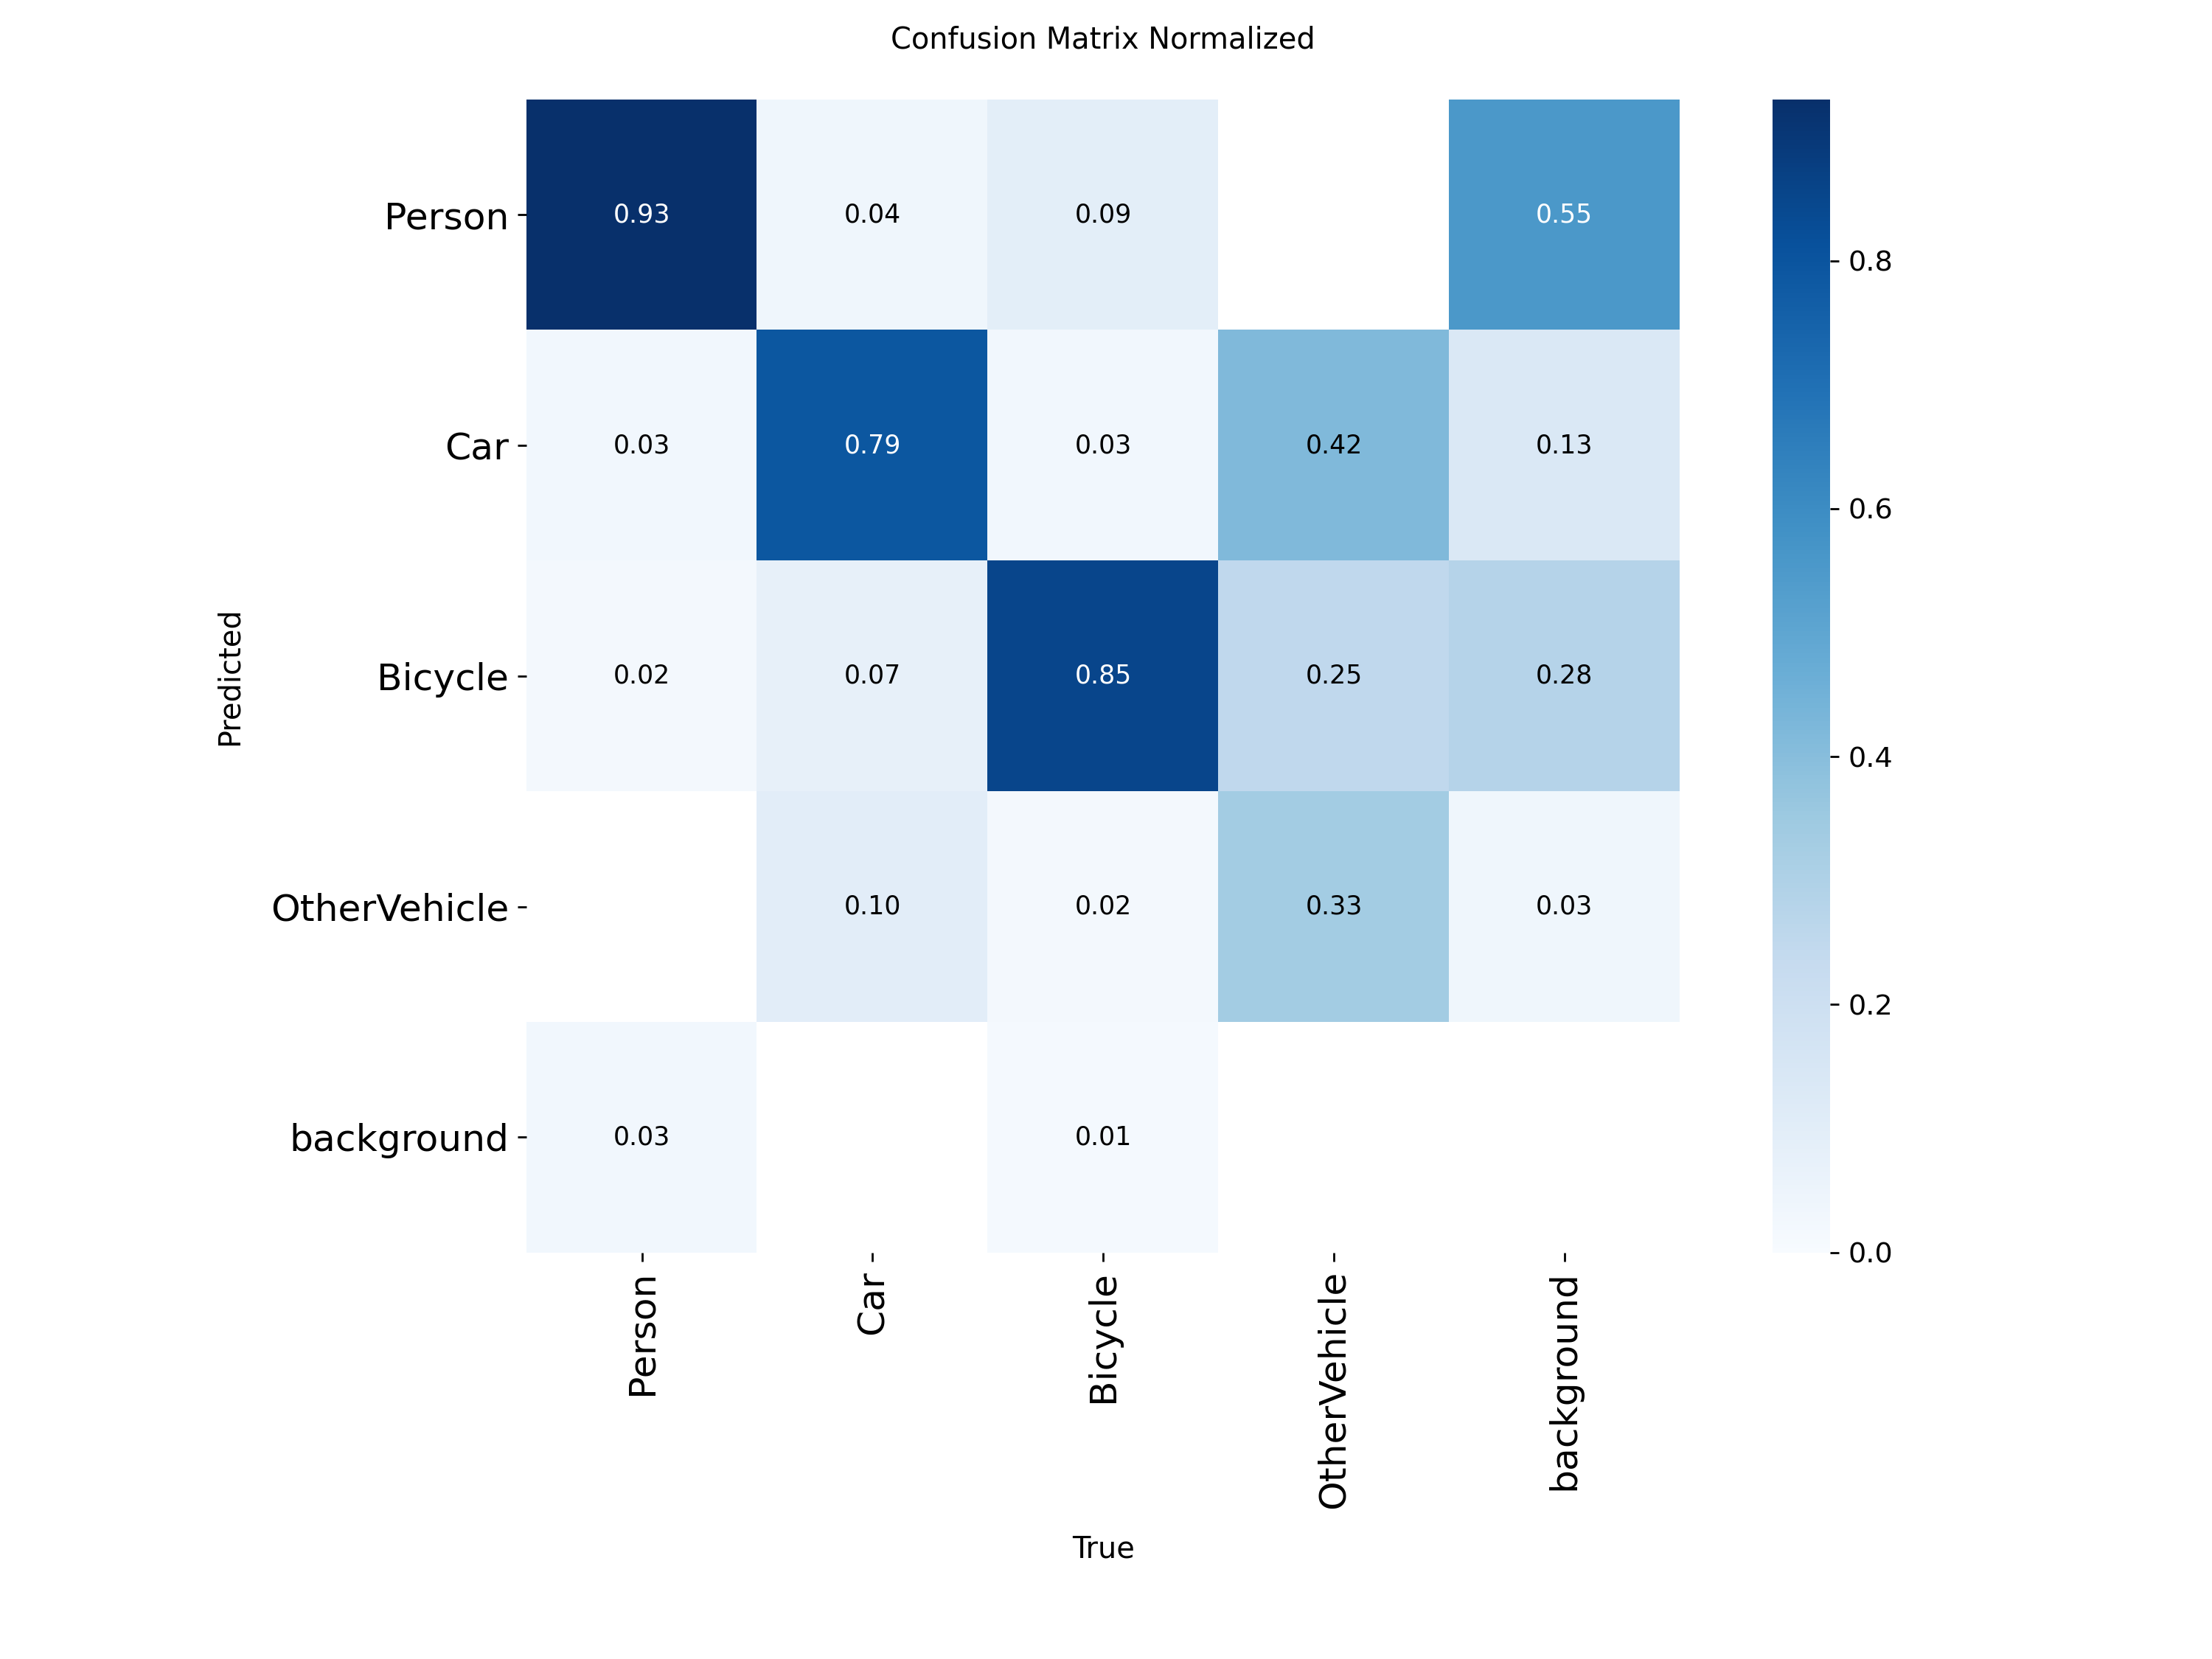

In [20]:
cm_png = "/content/runs/detect/runs_intruder_detection/hituav_yolov8n/confusion_matrix_normalized.png"
if os.path.exists(cm_png):
    display(Image(filename=cm_png))
else:
    print("Confusion matrix image not found in the run folder — check the path above.")

In [19]:
import random
test_img_dir = os.path.join(images_root, "images", "test")
sample_imgs = random.sample(os.listdir(test_img_dir), min(6, len(os.listdir(test_img_dir))))

results = finetuned_model.predict(
    [os.path.join(test_img_dir, f) for f in sample_imgs],
    conf=0.25, imgsz=640, save=False
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, r in zip(axes.flatten(), results):
    im = r.plot()  # numpy array with boxes drawn
    ax.imshow(im[..., ::-1])  # BGR -> RGB
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/sample_detections.png", dpi=150)
plt.show()


0: 512x640 4 Cars, 25 Bicycles, 6.6ms
1: 512x640 12 Persons, 6.6ms
2: 512x640 5 Persons, 6.6ms
3: 512x640 6 Persons, 6.6ms
4: 512x640 14 Cars, 6.6ms
5: 512x640 6 Cars, 6.6ms
Speed: 1.6ms preprocess, 6.6ms inference, 0.8ms postprocess per image at shape (1, 3, 512, 640)


NameError: name 'plt' is not defined

## 8. Training curves

Ultralytics auto-saves these during training — loss, precision, recall, and mAP across all epochs.

In [14]:
best_weights = "/content/runs/detect/runs_intruder_detection/hituav_yolov8n/weights/best.pt"
finetuned_model = YOLO(best_weights)

finetuned_metrics = finetuned_model.val(
    data="/content/hituav.yaml",
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.5,
    verbose=True,
)
print("Fine-tuned mAP50:", finetuned_metrics.box.map50)
print("Fine-tuned mAP50-95:", finetuned_metrics.box.map)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2192.6±807.9 MB/s, size: 69.3 KB)
val: Scanning /root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1/hit-uav/labels/test.cache... 571 images, 0 backgrounds, 23 corrupt: 100% ━━━━━━━━━━━━ 571/571 239.5Mit/s 0.0s
val: /root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1/hit-uav/images/test/0_130_60_0_09786.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 4. Possible class labels are 0-3
val: /root/.cache/kagglehub/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset/versions/1/hit-uav/images/test/0_60_30_0_01614.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 4. Possible class labels are 0-3
val: /root/.cache/kagg

In [15]:
from IPython.display import Image, display
results_png = "runs_intruder_detection/hituav_yolov8n/results.png"
if os.path.exists(results_png):
    display(Image(filename=results_png))
else:
    print("results.png not found — check the training run folder.")

results.png not found — check the training run folder.


## 9. Confusion matrix (fine-tuned model, test set)

In [16]:
cm_png = "runs_intruder_detection/hituav_yolov8n/confusion_matrix_normalized.png"
if os.path.exists(cm_png):
    display(Image(filename=cm_png))
else:
    print("Confusion matrix image not found in the run folder — check the path above.")

Confusion matrix image not found in the run folder — check the path above.


## 10. Save the fine-tuned model for download

Downloads `hituav_yolov8n_finetuned.pt` to your computer — this is the same model file you'd hand off for edge deployment testing (Jetson Orin-class hardware, per the platform's technical spec).

In [18]:
import shutil
shutil.copy(best_weights, "/content/hituav_yolov8n_finetuned.pt")

from google.colab import files
files.download("/content/hituav_yolov8n_finetuned.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Summary for the meeting

- **Dataset:** HIT-UAV (Suo et al., *Scientific Data*, 2023) — 2,898 real drone-captured infrared thermal images, 60–130 m altitude, day and night, 4 classes (Person, Car, Bicycle, OtherVehicle). Pulled live from Kaggle in this notebook.
- **Model:** YOLOv8n (~3.0M parameters) — smallest YOLOv8 variant, sized for the Jetson Orin-class edge compute (25–100 TOPS) named in the platform's technical document.
- **Result:** mAP@0.5 improved from the baseline (stock, untrained model) to the fine-tuned model — see the printed comparison and chart above for this run's exact numbers.
- **Why this matters:** it confirms the drone's detection layer needs models fine-tuned on domain-relevant (aerial, thermal) imagery — an off-the-shelf visible-light detector performs poorly on this kind of footage.

**Honest limitations, worth stating plainly to the team:**
- This measures accuracy on published HIT-UAV imagery, not on our own drone's actual gimbal/sensor or Bangladesh site conditions — real deployment accuracy still needs validation on Phase 2 field-pilot footage.
- This notebook only benchmarks the drone's *aerial* detection task. The UGV's ground-level detection and the loitering/anomaly-behavior layer are separate benchmarks, not covered here.
- Class balance in HIT-UAV favors Person and Car; Bicycle and OtherVehicle have far fewer examples, so their accuracy will likely lag the other two classes regardless of training budget, until more examples are added.
